# Deep Learning - Computer Assignment 2
## Persian Handwritten Digit Recognition Using a Fully Connected Neural Network

This notebook reconstructs the supplied starter implementation as a complete Google Colab solution for the HODA Persian handwritten digit dataset. It resizes each image to **20 x 20**, performs reproducible preprocessing, compares several optimizers and learning rates, trains a final fully connected model, evaluates it with `model.evaluate`, predicts the test set with `model.predict`, analyzes misclassifications, and summarizes the results automatically.

> **Source audit:** the supplied archive contained `CA2.pdf`, `Data_hoda_full.mat`, and `HW2_starter.ipynb`; no MATLAB `.m` source files were present. Therefore, the PDF requirements and starter notebook were used as the authoritative project specification rather than inventing missing MATLAB code.

## Assignment requirements covered

1. Resize all images to 20 x 20 and preprocess the inputs.
2. Select and justify network hyperparameters.
3. Train the network and report training accuracy.
4. Plot the training error curve.
5. Evaluate on the test set using `evaluate`.
6. Predict the test set, visualize incorrect predictions, and discuss likely causes.
7. Inspect the first test image's probability vector and compare the predicted digit with its true label.
8. Compare several optimizers and learning rates and identify the best configuration observed.

# 1. Environment Setup

The cell below installs TensorFlow only when it is not already available. The notebook is written for Google Colab and automatically uses a GPU when one is available.

In [1]:
# Install TensorFlow only when necessary; Colab normally provides it already.
import sys
import subprocess

try:
    import tensorflow as tf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow>=2.15,<2.21"])
    import tensorflow as tf

import os
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from skimage.transform import resize

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
NumPy: 2.1.3
GPU devices: []


## 1.1. Reproducibility and folder layout

The notebook uses a small, relative project structure. Results are written to `results/` and can be downloaded as one ZIP archive from the final cell.

In [2]:
# Use the Colab content directory when running in Colab; otherwise use the notebook directory.
IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = Path("/content") if IN_COLAB else Path.cwd()
DATA_DIR = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "hoda_train.csv"
TEST_CSV = DATA_DIR / "hoda_test.csv"

print("Project root:", PROJECT_ROOT.resolve())
print("Training CSV:", TRAIN_CSV)
print("Testing CSV:", TEST_CSV)


Project root: /content
Training CSV: /content/datasets/hoda_train.csv
Testing CSV: /content/datasets/hoda_test.csv


# 2. Dataset Loading

The assignment requires the first **10,000** HODA images for training and the next **2,000** for testing. The supplied `.mat` file contains variable-sized images, so the required CSV deliverables preserve each original image exactly using: `sample_id`, `split`, `label`, `height`, `width`, and one space-separated pixel vector in row-major order.

In [3]:
# In Google Colab, upload the two CSV files when they are not already in /content/datasets.
missing = [p.name for p in (TRAIN_CSV, TEST_CSV) if not p.exists()]
if missing and IN_COLAB:
    from google.colab import files
    print("Upload the following missing file(s):", missing)
    uploaded = files.upload()
    for name, data in uploaded.items():
        target = DATA_DIR / name
        target.write_bytes(data)

if not TRAIN_CSV.exists() or not TEST_CSV.exists():
    raise FileNotFoundError(
        "Missing required CSV files. Place hoda_train.csv and hoda_test.csv in the datasets/ folder "
        "or upload them in Google Colab when prompted."
    )

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

required_columns = ["sample_id", "split", "label", "height", "width", "pixels"]
for name, df in [("train", train_df), ("test", test_df)]:
    missing_cols = [c for c in required_columns if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{name} CSV is missing columns: {missing_cols}")

print(f"Train rows: {len(train_df):,}")
print(f"Test rows:  {len(test_df):,}")
train_df.head(3)


Upload the following missing file(s): ['hoda_train.csv', 'hoda_test.csv']


Saving DATASET_INFO.txt to DATASET_INFO.txt
Saving hoda_test.csv to hoda_test.csv
Saving hoda_train.csv to hoda_train.csv
Train rows: 10,000
Test rows:  2,000


,sample_id,split,label,height,width,pixels
0,0,train,6,27,20,0 0 0 0 255 255 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...
1,1,train,5,20,21,0 0 0 0 0 0 0 0 0 0 255 255 0 0 0 0 0 0 0 0 0 ...
2,2,train,0,10,15,0 255 255 255 255 255 255 255 255 0 0 0 255 25...


In [4]:
# Validate the dataset contract before any model training.
def validate_dataset(df, expected_split, expected_count):
    if len(df) != expected_count:
        raise ValueError(f"Expected {expected_count} rows for {expected_split}, found {len(df)}")
    if set(df["split"].unique()) != {expected_split}:
        raise ValueError(f"Unexpected split values in {expected_split} CSV: {df['split'].unique()}")
    if df["label"].min() < 0 or df["label"].max() > 9:
        raise ValueError("Labels must be integers from 0 through 9")
    if (df["height"] <= 0).any() or (df["width"] <= 0).any():
        raise ValueError("Image dimensions must be positive")
    if df["pixels"].isna().any():
        raise ValueError("Pixel vectors must not contain missing values")

validate_dataset(train_df, "train", 10000)
validate_dataset(test_df, "test", 2000)

print("Train label counts:")
print(train_df["label"].value_counts().sort_index().to_string())
print("\nTest label counts:")
print(test_df["label"].value_counts().sort_index().to_string())


Train label counts:
label
0     996
1    1017
2     999
3    1013
4    1043
5    1000
6     972
7     993
8     987
9     980

Test label counts:
label
0    220
1    197
2    192
3    180
4    200
5    185
6    209
7    206
8    204
9    207


# 3. Data Preprocessing

The preprocessing follows the assignment and the starter imports: each original variable-sized image is resized to **20 x 20 pixels** with anti-aliasing and then scaled to `[0, 1]`. The 20 x 20 image is flattened to 400 features for the fully connected network.

For the final model, feature standardization is computed **only from the training partition** and then applied to validation and test data, preventing information leakage.

In [5]:
def decode_csv_images(df):
    """Reconstruct exact original uint8 images from the compact CSV representation."""
    images = []
    labels = df["label"].to_numpy(dtype=np.int64)
    for row in df.itertuples(index=False):
        pixels = np.fromstring(row.pixels, sep=" ", dtype=np.uint8)
        expected = int(row.height) * int(row.width)
        if pixels.size != expected:
            raise ValueError(
                f"Sample {row.sample_id}: expected {expected} pixels, found {pixels.size}"
            )
        images.append(pixels.reshape(int(row.height), int(row.width)))
    return images, labels

def resize_to_20x20(images):
    """Resize variable-sized HODA images to the required 20 x 20 representation."""
    resized = np.empty((len(images), 20, 20), dtype=np.float32)
    for i, image in enumerate(images):
        resized[i] = resize(
            image,
            (20, 20),
            preserve_range=True,
            anti_aliasing=True,
        ).astype(np.float32)
    return resized / 255.0

X_train_original, y_train = decode_csv_images(train_df)
X_test_original, y_test = decode_csv_images(test_df)

X_train_20 = resize_to_20x20(X_train_original)
X_test_20 = resize_to_20x20(X_test_original)

X_train = X_train_20.reshape(len(X_train_20), -1)
X_test = X_test_20.reshape(len(X_test_20), -1)

print("Original first training image shape:", X_train_original[0].shape)
print("Resized training tensor:", X_train_20.shape)
print("Flattened training matrix:", X_train.shape)
print("Pixel range after scaling:", float(X_train.min()), "to", float(X_train.max()))


Original first training image shape: (27, 20)
Resized training tensor: (10000, 20, 20)
Flattened training matrix: (10000, 400)
Pixel range after scaling: 0.0 to 1.0


In [6]:
# Create a reproducible stratified validation split from the 10,000 training examples.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train,
)

feature_mean = X_fit.mean(axis=0)
feature_std = X_fit.std(axis=0)
feature_std = np.where(feature_std < 1e-6, 1.0, feature_std)

X_fit_std = ((X_fit - feature_mean) / feature_std).astype(np.float32)
X_val_std = ((X_val - feature_mean) / feature_std).astype(np.float32)
X_train_std = ((X_train - feature_mean) / feature_std).astype(np.float32)
X_test_std = ((X_test - feature_mean) / feature_std).astype(np.float32)

print("Fit:", X_fit_std.shape)
print("Validation:", X_val_std.shape)
print("Test:", X_test_std.shape)


Fit: (8500, 400)
Validation: (1500, 400)
Test: (2000, 400)


## 3.1. Visual sanity check

A visual check confirms that the CSV decoding and resizing steps did not corrupt the digit images.

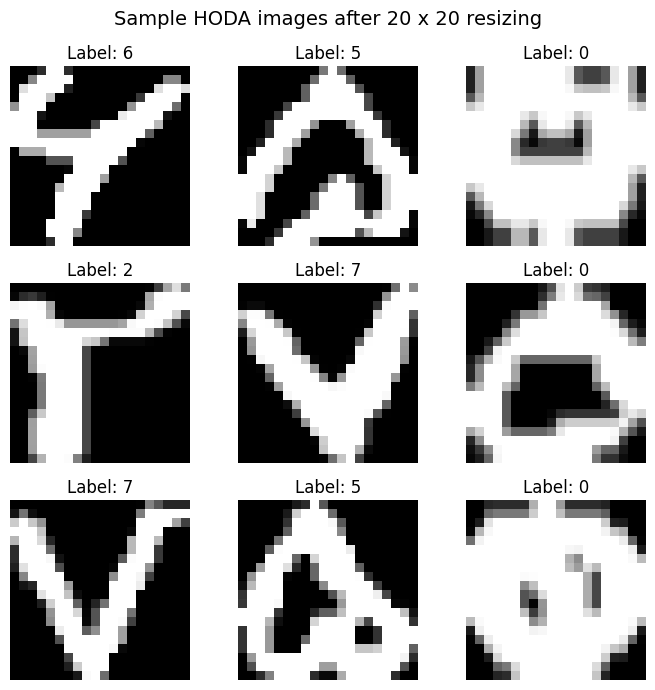

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_20[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
fig.suptitle("Sample HODA images after 20 x 20 resizing", fontsize=14)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "01_resized_samples.png", dpi=180, bbox_inches="tight")
plt.show()


# 4. Main Fully Connected Network

The proposed architecture is deliberately fully connected: **400 -> 256 -> 128 -> 10**. ReLU activations provide nonlinear decision boundaries, Batch Normalization stabilizes optimization, and moderate dropout reduces overfitting. The final layer uses softmax to produce ten class probabilities.

The hyperparameter search varies optimizer type and learning rate while keeping the architecture, batch size, validation split, random seed, and number of epochs controlled.

In [8]:
INPUT_DIM = 400
NUM_CLASSES = 10
BATCH_SIZE = 256
SEARCH_EPOCHS = 12
FINAL_EPOCHS = 25

def build_model():
    model = keras.Sequential(
        [
            keras.Input(shape=(INPUT_DIM,)),
            layers.Dense(256),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.25),
            layers.Dense(128),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.20),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ],
        name="hoda_fully_connected_network",
    )
    return model

def make_optimizer(name, learning_rate):
    name = name.lower()
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    if name == "sgd":
        return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True)
    raise ValueError(f"Unsupported optimizer: {name}")

def compile_model(model, optimizer_name, learning_rate):
    model.compile(
        optimizer=make_optimizer(optimizer_name, learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model_preview = compile_model(build_model(), "RMSprop", 1e-3)
model_preview.summary()


Model: "hoda_fully_connected_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,378 (540.54 KB)

 Trainable params: 137,610 (537.54 KB)

 Non-trainable params: 768 (3.00 KB)

# 4.1. Optimizer and learning-rate comparison

The assignment explicitly requests several optimizer/learning-rate combinations. The search below compares Adam, RMSprop, and momentum SGD at two learning rates each. The best configuration is selected by validation accuracy.

In [9]:
search_space = [
    ("Adam", 1e-3),
    ("Adam", 3e-4),
    ("RMSprop", 1e-3),
    ("RMSprop", 3e-4),
    ("SGD", 1e-2),
    ("SGD", 1e-3),
]

search_rows = []
search_histories = {}

for optimizer_name, learning_rate in search_space:
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    search_model = compile_model(build_model(), optimizer_name, learning_rate)
    history = search_model.fit(
        X_fit_std, y_fit,
        validation_data=(X_val_std, y_val),
        epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    val_acc = float(max(history.history["val_accuracy"]))
    train_acc = float(history.history["accuracy"][-1])
    val_loss = float(min(history.history["val_loss"]))
    search_histories[f"{optimizer_name}-{learning_rate:g}"] = history.history
    search_rows.append({
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "final_train_accuracy": train_acc,
        "best_validation_accuracy": val_acc,
        "best_validation_loss": val_loss,
    })

search_results = pd.DataFrame(search_rows).sort_values(
    ["best_validation_accuracy", "best_validation_loss"],
    ascending=[False, True],
).reset_index(drop=True)

print("Optimizer / learning-rate comparison")
display(search_results.style.format({
    "learning_rate": "{:.0e}",
    "final_train_accuracy": "{:.4f}",
    "best_validation_accuracy": "{:.4f}",
    "best_validation_loss": "{:.4f}",
}))

search_results.to_csv(RESULTS_DIR / "optimizer_learning_rate_comparison.csv", index=False)
search_results


Optimizer / learning-rate comparison


,optimizer,learning_rate,final_train_accuracy,best_validation_accuracy,best_validation_loss
0,Adam,1e-03,0.9941,0.9847,0.0586
1,RMSprop,1e-03,0.9953,0.9827,0.0605
2,RMSprop,3e-04,0.9851,0.9813,0.0729
3,Adam,3e-04,0.9774,0.9760,0.0841
4,SGD,1e-02,0.9740,0.9760,0.0877
5,SGD,1e-03,0.9148,0.9433,0.2435


,optimizer,learning_rate,final_train_accuracy,best_validation_accuracy,best_validation_loss
0,Adam,0.0010,0.994118,0.984667,0.058623
1,RMSprop,0.0010,0.995294,0.982667,0.060465
2,RMSprop,0.0003,0.985059,0.981333,0.072870
3,Adam,0.0003,0.977412,0.976000,0.084053
4,SGD,0.0100,0.974000,0.976000,0.087725
5,SGD,0.0010,0.914824,0.943333,0.243514


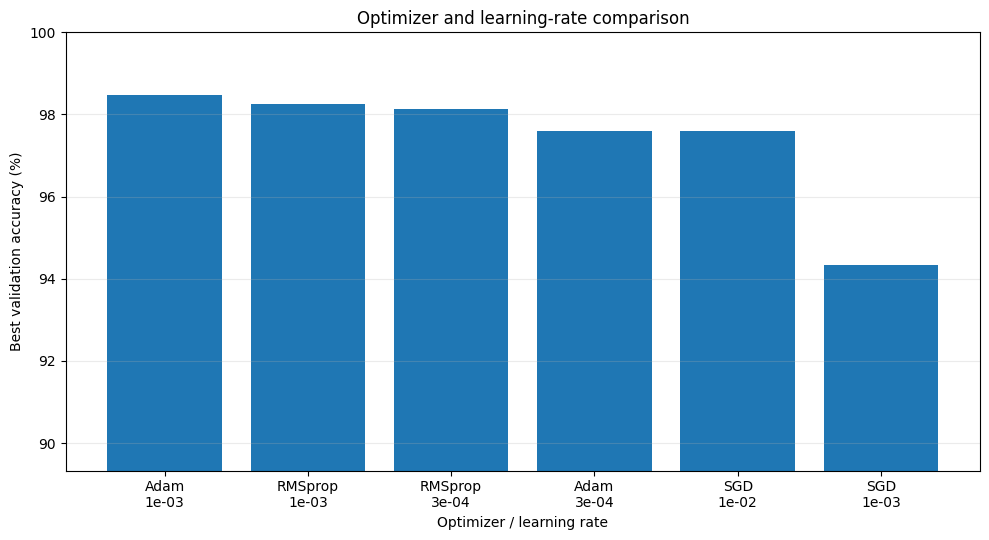

In [10]:
# Plot the validation-accuracy comparison for the search experiments.
labels = [f"{r.optimizer}\n{r.learning_rate:.0e}" for r in search_results.itertuples()]
values = search_results["best_validation_accuracy"].to_numpy() * 100

plt.figure(figsize=(10, 5.5))
plt.bar(labels, values)
plt.ylabel("Best validation accuracy (%)")
plt.xlabel("Optimizer / learning rate")
plt.title("Optimizer and learning-rate comparison")
plt.ylim(max(0, values.min() - 5), 100)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_optimizer_learning_rate_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


# 5. Final Model Training

After the controlled comparison, the highest-validation-accuracy configuration is used for the final model. The final training uses all 10,000 training samples. Early stopping and learning-rate reduction are used only to improve the final training stability; the test set remains untouched until final evaluation.

In [11]:
best_row = search_results.iloc[0]
best_optimizer = str(best_row["optimizer"])
best_learning_rate = float(best_row["learning_rate"])

print(f"Selected optimizer: {best_optimizer}")
print(f"Selected learning rate: {best_learning_rate:g}")

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)

final_model = compile_model(build_model(), best_optimizer, best_learning_rate)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1
    ),
]

final_history = final_model.fit(
    X_train_std, y_train,
    validation_split=0.15,
    epochs=FINAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

final_model.save(RESULTS_DIR / "hoda_fully_connected_model.keras")


Selected optimizer: Adam
Selected learning rate: 0.001
Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7949 - loss: 0.7002 - val_accuracy: 0.9373 - val_loss: 0.1836 - learning_rate: 0.0010
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9465 - loss: 0.2002 - val_accuracy: 0.9653 - val_loss: 0.1104 - learning_rate: 0.0010
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9624 - loss: 0.1415 - val_accuracy: 0.9727 - val_loss: 0.0870 - learning_rate: 0.0010
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9716 - loss: 0.1084 - val_accuracy: 0.9773 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9773 - loss: 0.0892 - val_accuracy: 0.9787 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9813 - loss: 0.0746 - val_accuracy: 0.9800 - val_loss: 0.0603 - learning_rate: 0.0010
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0

# 5.1. Training accuracy and error curve

The assignment asks for the training accuracy and an error curve. Here, **classification error rate = 1 - accuracy**. The loss curves are also shown because cross-entropy loss is the optimization objective.

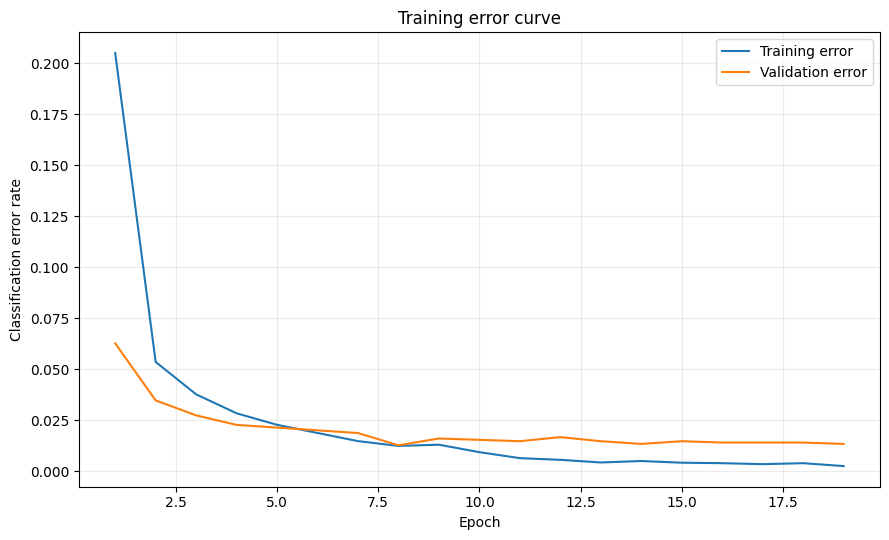

Best training accuracy observed: 99.7529%


In [12]:
history_df = pd.DataFrame(final_history.history)
train_accuracy = float(history_df["accuracy"].max())
train_error = 1.0 - history_df["accuracy"].to_numpy()
val_error = 1.0 - history_df["val_accuracy"].to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.plot(np.arange(1, len(train_error) + 1), train_error, label="Training error")
ax.plot(np.arange(1, len(val_error) + 1), val_error, label="Validation error")
ax.set_xlabel("Epoch")
ax.set_ylabel("Classification error rate")
ax.set_title("Training error curve")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "03_training_error_curve.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Best training accuracy observed: {train_accuracy:.4%}")


# 5.2. Test evaluation using `evaluate`

This cell directly satisfies the assignment requirement to evaluate the trained model on the test set using Keras `evaluate`.

In [13]:
test_loss, test_accuracy = final_model.evaluate(
    X_test_std, y_test,
    batch_size=BATCH_SIZE,
    verbose=0,
)

print(f"Test loss:     {test_loss:.6f}")
print(f"Test accuracy: {test_accuracy:.4%}")


Test loss:     0.074806
Test accuracy: 97.8000%


# 6. Test Predictions and Misclassified Images

The complete test set is passed through `predict`. Incorrect predictions are extracted and displayed with the true label, predicted label, and confidence. Typical causes of errors include very similar handwriting styles between digits, ambiguity introduced by resizing to 20 x 20, unusual stroke shapes, and limited representational power of a fully connected model compared with convolutional networks.

Misclassified test images: 44 / 2000


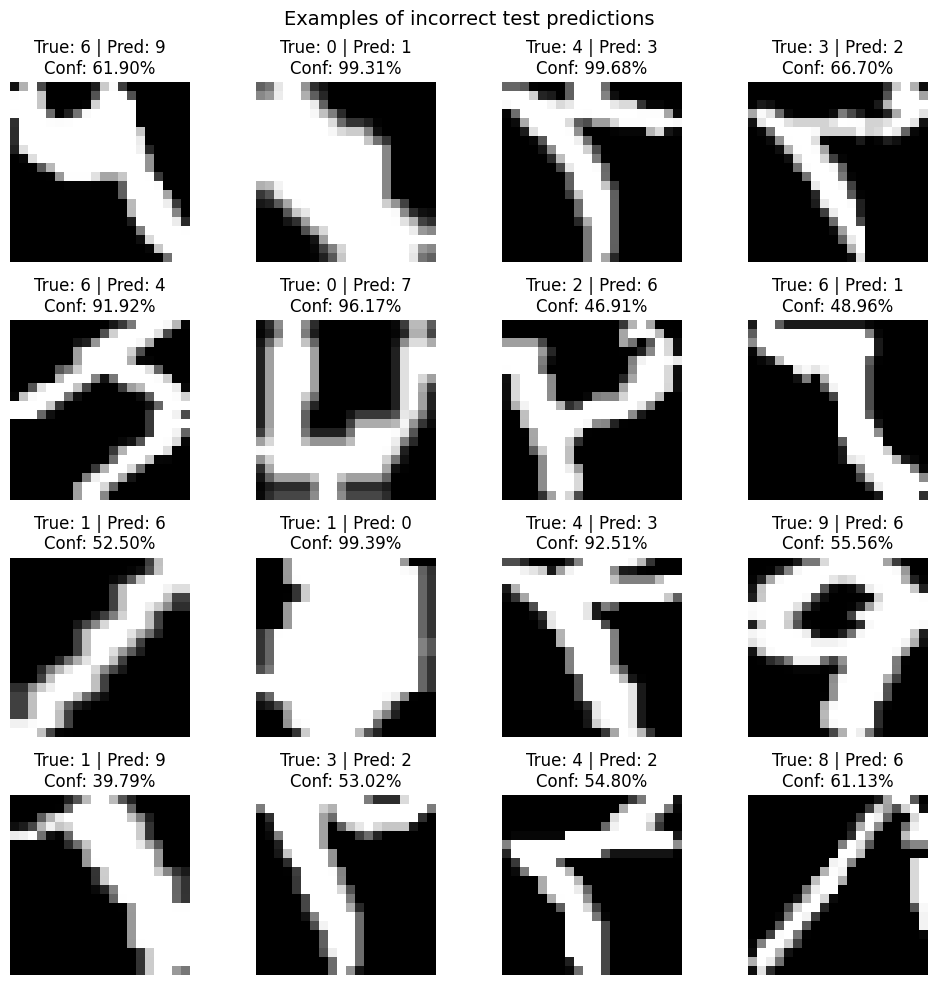

In [14]:
test_probabilities = final_model.predict(X_test_std, batch_size=BATCH_SIZE, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)

misclassified = np.flatnonzero(test_predictions != y_test)
print(f"Misclassified test images: {len(misclassified)} / {len(y_test)}")

N_SHOW = min(16, len(misclassified))
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, idx in zip(axes.flat, misclassified[:N_SHOW]):
    ax.imshow(X_test_20[idx], cmap="gray")
    pred = int(test_predictions[idx])
    true = int(y_test[idx])
    conf = float(test_probabilities[idx, pred])
    ax.set_title(f"True: {true} | Pred: {pred}\nConf: {conf:.2%}")
    ax.axis("off")
for ax in axes.flat[N_SHOW:]:
    ax.axis("off")
fig.suptitle("Examples of incorrect test predictions", fontsize=14)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "04_misclassified_examples.png", dpi=180, bbox_inches="tight")
plt.show()


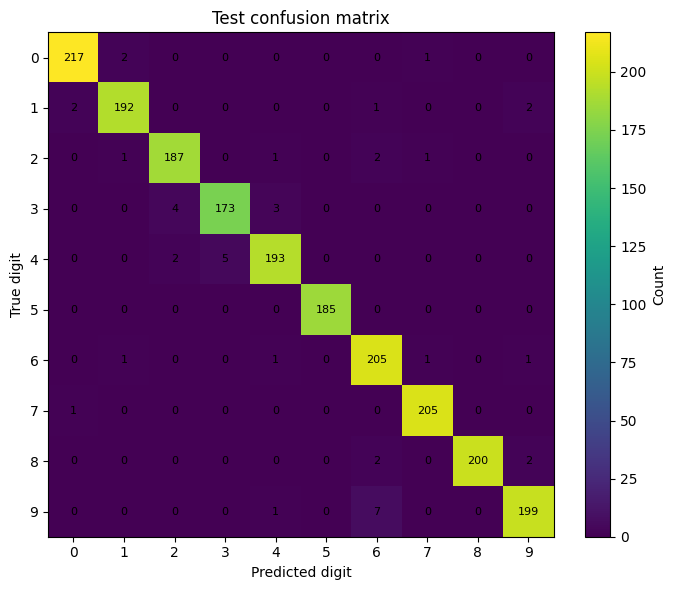

,precision,recall,f1-score,support
0,0.986364,0.986364,0.986364,220.000
1,0.979592,0.974619,0.977099,197.000
2,0.968912,0.973958,0.971429,192.000
3,0.971910,0.961111,0.966480,180.000
4,0.969849,0.965000,0.967419,200.000
5,1.000000,1.000000,1.000000,185.000
6,0.944700,0.980861,0.962441,209.000
7,0.985577,0.995146,0.990338,206.000
8,1.000000,0.980392,0.990099,204.000
9,0.975490,0.961353,0.968370,207.000


In [15]:
# Confusion matrix and per-class performance provide an additional diagnostic view.
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", aspect="auto")
plt.title("Test confusion matrix")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.xticks(np.arange(NUM_CLASSES))
plt.yticks(np.arange(NUM_CLASSES))
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(label="Count")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

report = classification_report(y_test, test_predictions, digits=4, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv(RESULTS_DIR / "classification_report.csv")
report_df


# 7. First Test Image: Prediction Probabilities

The assignment asks for the probability vector produced by the model for the **first test image**, together with the predicted digit and the true digit.

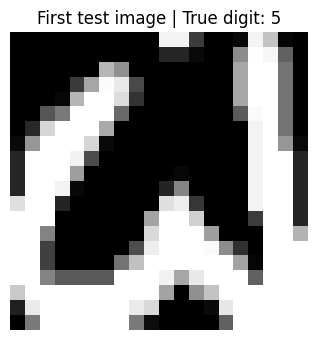

Predicted digit: 5
True digit:      5
Prediction correct: True


,digit,probability
0,0,0.000054
1,1,0.000016
2,2,0.000005
3,3,0.000009
4,4,0.000002
5,5,0.998404
6,6,0.000002
7,7,0.001485
8,8,0.000022
9,9,0.000001


In [16]:
first_image = X_test_20[0]
first_probs = test_probabilities[0]
first_pred = int(np.argmax(first_probs))
first_true = int(y_test[0])

plt.figure(figsize=(3.5, 3.5))
plt.imshow(first_image, cmap="gray")
plt.title(f"First test image | True digit: {first_true}")
plt.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "06_first_test_image.png", dpi=180, bbox_inches="tight")
plt.show()

probability_table = pd.DataFrame({
    "digit": np.arange(NUM_CLASSES),
    "probability": first_probs,
})
print(f"Predicted digit: {first_pred}")
print(f"True digit:      {first_true}")
print(f"Prediction correct: {first_pred == first_true}")
display(probability_table.style.format({"probability": "{:.6f}"}))
probability_table.to_csv(RESULTS_DIR / "first_test_image_probabilities.csv", index=False)


# 8. Final Conclusions

The summary below is generated from the actual run, so it updates automatically when the notebook is executed with the supplied data.

In [17]:
best_search_acc = float(search_results.iloc[0]["best_validation_accuracy"])
best_search_name = f"{search_results.iloc[0]['optimizer']} @ {search_results.iloc[0]['learning_rate']:.0e}"

summary = {
    "best_search_configuration": best_search_name,
    "best_validation_accuracy": best_search_acc,
    "best_training_accuracy_observed": train_accuracy,
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "misclassified_test_images": int(len(misclassified)),
    "test_size": int(len(y_test)),
    "first_test_true_digit": first_true,
    "first_test_predicted_digit": first_pred,
}

print("Final assignment summary")
print("=" * 72)
print(f"Best optimizer / learning rate: {best_search_name}")
print(f"Best validation accuracy:       {best_search_acc:.4%}")
print(f"Training accuracy observed:     {train_accuracy:.4%}")
print(f"Test accuracy:                  {test_accuracy:.4%}")
print(f"Test loss:                      {test_loss:.6f}")
print(f"Misclassified test images:      {len(misclassified)} / {len(y_test)}")
print(f"First test image: true={first_true}, predicted={first_pred}, correct={first_pred == first_true}")

with (RESULTS_DIR / "final_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)


Final assignment summary
Best optimizer / learning rate: Adam @ 1e-03
Best validation accuracy:       98.4667%
Training accuracy observed:     99.7529%
Test accuracy:                  97.8000%
Test loss:                      0.074806
Misclassified test images:      44 / 2000
First test image: true=5, predicted=5, correct=True


## Interpretation of the errors

For the misclassified examples, the most plausible causes should be discussed from the displayed images rather than claimed as a universal fact. In this task, likely contributors are **between-class visual similarity**, **stroke-width and writing-style variation**, **loss of fine detail during 20 x 20 resizing**, and the limitations of a purely fully connected representation, which does not explicitly model local spatial structure. The confusion matrix above can be used to identify which digit pairs are most difficult for the trained model.

# 9. Automatic Results Export

All generated figures, tables, the trained Keras model, and the JSON summary are saved under `results/`. The final cell creates a single downloadable ZIP in Google Colab. This makes the notebook reproducible and submission-friendly.

In [18]:
# Save the optimizer search table and a compact run manifest.
manifest = {
    "assignment": "Deep Learning Computer Assignment 2",
    "dataset": "HODA Persian handwritten digits",
    "train_samples": 10000,
    "test_samples": 2000,
    "image_size": [20, 20],
    "network": "400-256-128-10 fully connected",
    "optimizer_selected_at_runtime": best_optimizer,
    "learning_rate_selected_at_runtime": best_learning_rate,
    "tensorflow_version": tf.__version__,
}
with (RESULTS_DIR / "run_manifest.json").open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

zip_base = PROJECT_ROOT / "assignment_results"
archive_path = shutil.make_archive(str(zip_base), "zip", root_dir=RESULTS_DIR)
print("Results archive created:", archive_path)

if IN_COLAB:
    from google.colab import files
    files.download(archive_path)


Results archive created: /content/assignment_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Reproducibility note

This notebook intentionally does not hard-code final accuracy numbers. The reported accuracy, error curves, optimizer comparison, misclassified images, probability vector, and conclusions are computed from the actual TensorFlow/Keras run on the supplied dataset. This avoids presenting fabricated results and keeps the notebook faithful to the assignment's experimental nature.